In [1]:
import os
import sys
import matplotlib.pyplot as plt
from matplotlib.pylab import mpl
import numpy as np
import pandas as pd
import pickle
import copy
from data_evaluation_API import data_evaluation as eval
from Influxdb_API.Influxdb_API import ClientInfluxdb
%matplotlib inline

# 1. 以单组数据为例
### 1.1 从Influxdb_API获取数据
以电表数据为例  

In [2]:
db_name = 'moserveribms'
params = {
    'measurement_name': 'ibmsV2modata',
    'start_time': pd.to_datetime('2022-07-01 00:00:00'),
    'end_time': pd.to_datetime('2022-10-01 00:00:00'),
    'field_list': ['E'],
    'tag_dict': {'nid': 'ibmsv2/ibmsv2_5929149262402256896/EMeter/mDev_EMeter_Roof_MDV_10'},
    'fore': False,
    'fore_horizon': None,
    'interval': None
}
db_client = ClientInfluxdb(db_name=db_name) 
df = db_client.read_influxdb(**params)
print('data acquired\n------------------')

data acquired
------------------


### 1.2 设定相关处理参数，对数据进行必要的前处理
将从数据库中获取的数据的字符类型转换为float类型  
进行重采样

In [3]:
params_process={
    'rsp_time': pd.Timedelta('15 min'),
    'rsp_num': 4, # 4 times per hour
    'step': 4*24*3,  # to calculate missing rate, step=4/h*24h/day*3day表示计算每个时刻向前回溯三天的数据缺失率
    'ms_thresh': 0.2, # the condition of missing rate (< ms_thresh) for multivariables
    'imputation_time_delta': pd.Timedelta('6 hours'), # 连续缺失超过imputation_time_delta的数据将不会被插补
    'window': 4*24*3, # parameter for remove outliers
}
# str -> np.float64
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')
# resampling data, rsp_time=15min
df = eval.resampling(df, **params_process)
print(df)

                           E
2022-07-01 00:00:00  1051.71
2022-07-01 00:15:00  1051.92
2022-07-01 00:30:00  1051.92
2022-07-01 00:45:00  1052.11
2022-07-01 01:00:00  1052.11
...                      ...
2022-09-30 12:00:00      NaN
2022-09-30 12:15:00      NaN
2022-09-30 12:30:00      NaN
2022-09-30 12:45:00  3038.98
2022-09-30 13:00:00  3038.98

[8789 rows x 1 columns]


### 1.3 计算原始数据/去除异常值数据/数据插补后的数据缺失率，并输出最优最近的时刻
params_process['step'] = 4/h * 24h/day * 3day 表示计算每个时刻向前回溯3天的数据缺失率

1.3.1 计算原始数据的数据缺失率

E minimal missing rate:  0.0
E average missing rate:  0.5462837859192645
E the closest optimal moment to the present:  2022-09-07 14:15:00 
------------------


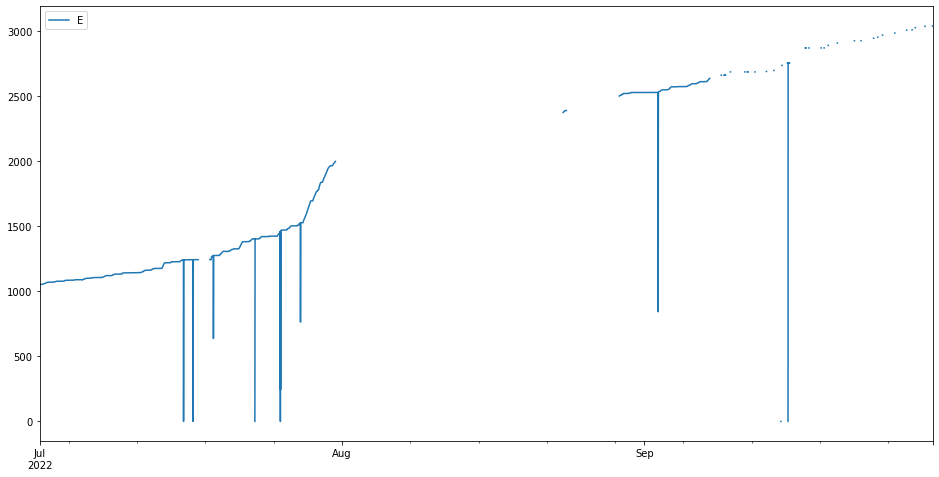

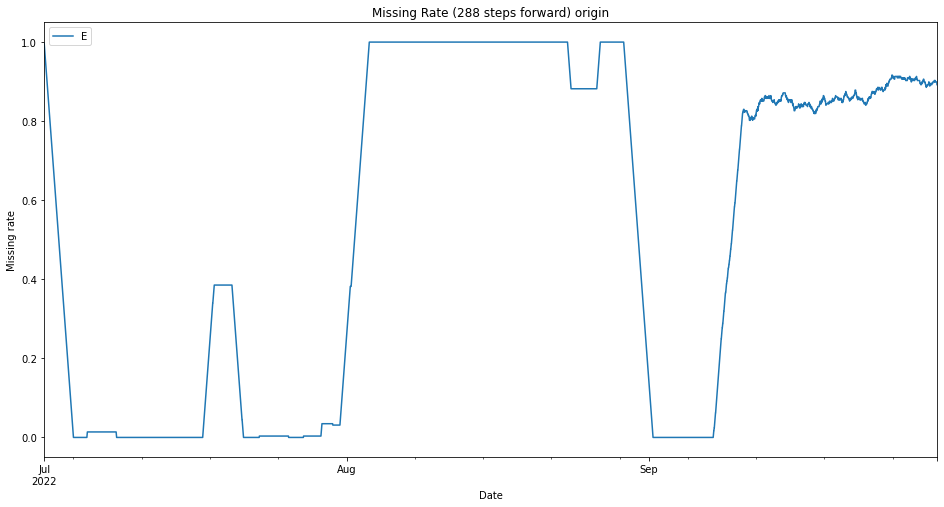

In [4]:
missing_rate = eval.cal_missing_rate(df, **params_process)

df.plot()
plt.legend(loc = 'upper left')
plt.gcf().set_size_inches(16, 8)
plt.show()

missing_rate.plot()
plt.plot(missing_rate.index, missing_rate)
plt.title('Missing Rate (' + str(params_process['step']) + ' steps forward) ' + 'origin')
plt.xlabel("Date")
plt.ylabel("Missing rate")
plt.legend(loc = 'upper left')
plt.gcf().set_size_inches(16, 8)
plt.show()

1.3.2 计算去除异常值后的数据缺失率

E minimal missing rate:  0.0
E average missing rate:  0.5490144720041426
E the closest optimal moment to the present:  2022-09-07 14:00:00 
------------------


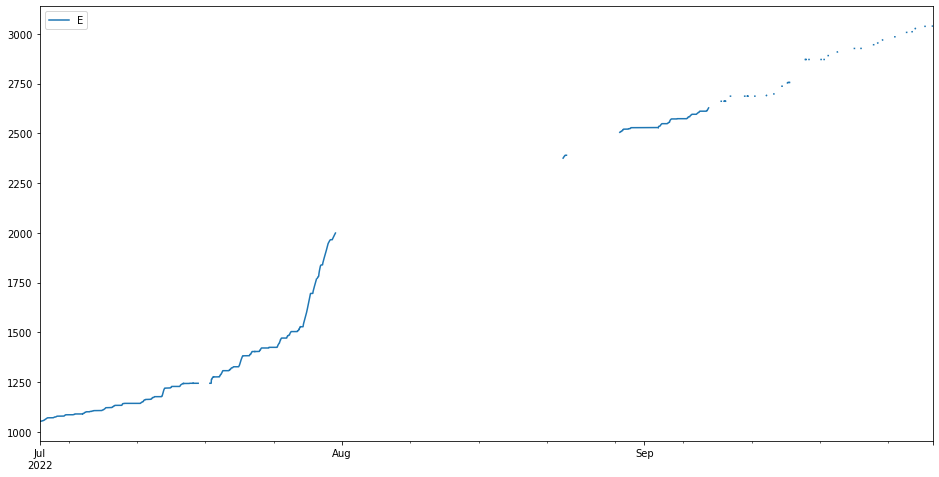

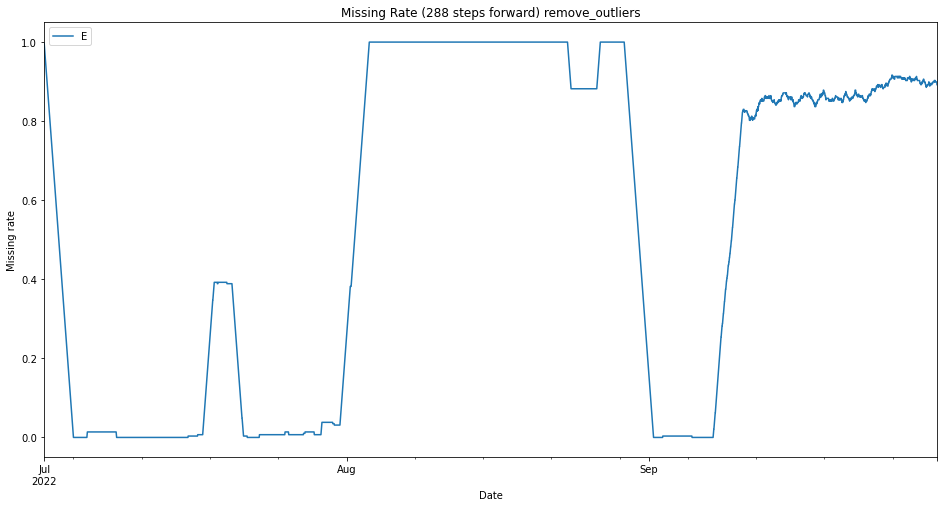

In [5]:
df_process = eval.remove_outliers(df, **params_process)
missing_rate_process = eval.cal_missing_rate(df_process, **params_process)

df_process.plot()
plt.legend(loc = 'upper left')
plt.gcf().set_size_inches(16, 8)
plt.show()

missing_rate_process.plot()
plt.plot(missing_rate_process.index, missing_rate_process)
plt.title('Missing Rate (' + str(params_process['step']) + ' steps forward) ' + 'remove_outliers')
plt.xlabel("Date")
plt.ylabel("Missing rate")
plt.legend(loc = 'upper left')
plt.gcf().set_size_inches(16, 8)
plt.show()

1.3.3 计算数据插补后的数据缺失率

E minimal missing rate:  0.0
E average missing rate:  0.38055342220704924
E the closest optimal moment to the present:  2022-09-23 05:15:00 
------------------


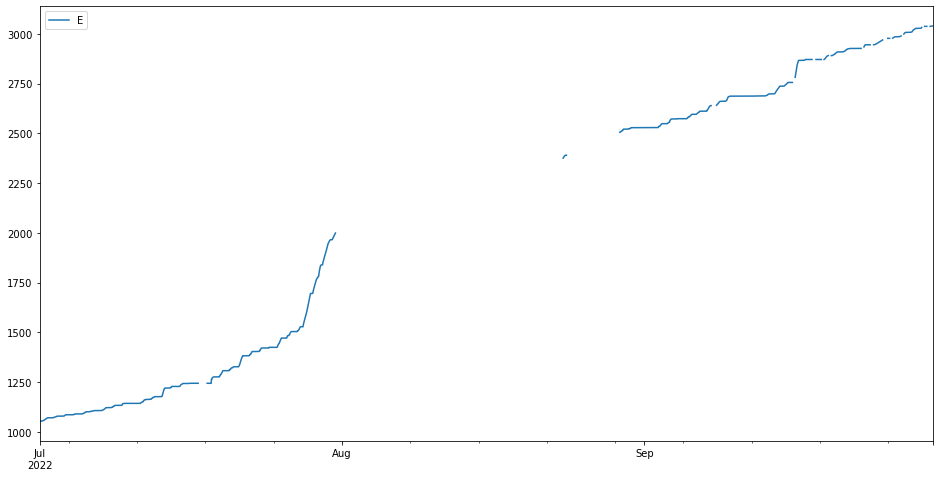

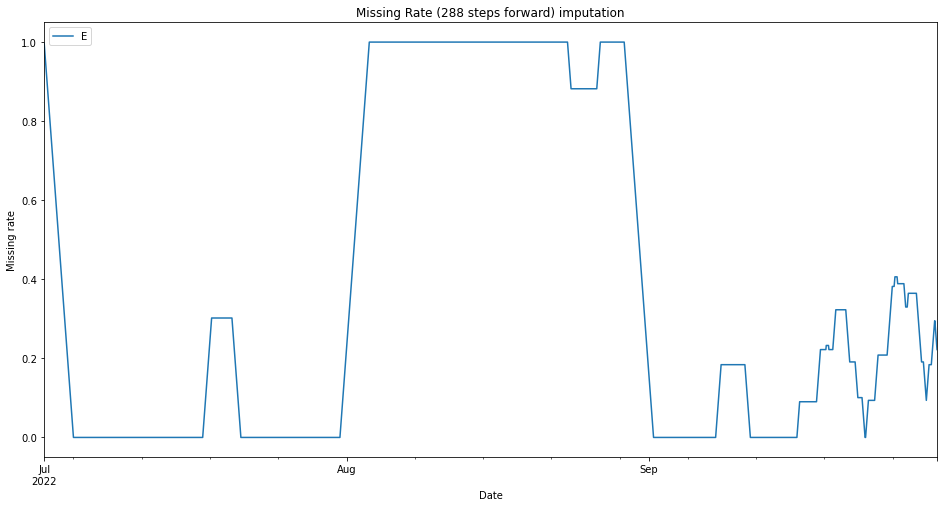

In [6]:
df_new = eval.linear_imputation(df_process, **params_process)
missing_rate_new = eval.cal_missing_rate(df_new, **params_process)

df_new.plot()
plt.legend(loc = 'upper left')
plt.gcf().set_size_inches(16, 8)
plt.show()

missing_rate_new.plot()
plt.plot(missing_rate_new.index, missing_rate_new)
plt.title('Missing Rate (' + str(params_process['step']) + ' steps forward) ' + 'imputation')
plt.xlabel("Date")
plt.ylabel("Missing rate")
plt.legend(loc = 'upper left')
plt.gcf().set_size_inches(16, 8)
plt.show()

# 2. 以多组数据为例
### 2.1 从Influxdb_API获取数据
1K0V多联机0号室内机的温度数据与多联机用电数据与天气数据

In [7]:
db_name = 'moserveribms'
params = {
    'measurement_name': 'ibmsV2modata',
    'start_time': pd.to_datetime('2022-07-01 00:00:00'),
    'end_time': pd.to_datetime('2022-10-01 00:00:00'),
    'field_list': ['E'],
    'tag_dict': {'nid': 'ibmsv2/ibmsv2_5929149262402256896/EMeter/mDev_EMeter_Roof_MDV_10'},
    'fore': False,
    'fore_horizon': None,
    'interval': None
}
db_client = ClientInfluxdb(db_name=db_name) 
df = db_client.read_influxdb(**params)
# str -> np.float64
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')
# resampling data, rsp_time=15min
df = eval.resampling(df)

db_name_temp='moserver'
params_temp={
    'measurement_name':'modata',
    'start_time': pd.to_datetime('2022-07-01 00:00:00'),
    'end_time': pd.to_datetime('2022-10-01 00:00:00'),
    'field_list': ['roomTemp'],
    'tag_dict': {'nid': 'vrf/vrf_0000CC311178CCM26232341000271K0V/indoor/0'},
    'fore': False,
    'fore_horizon': None,
    'interval': None
}
db_client_temp = ClientInfluxdb(db_name=db_name_temp) 
df_temp = db_client_temp.read_influxdb(**params_temp)
# str -> np.float64
for col in df_temp.columns:
    df_temp[col] = pd.to_numeric(df_temp[col], errors='ignore')
# resampling data, rsp_time=15min
df_temp = eval.resampling(df_temp)
df = df.join(df_temp)

db_name_temp='moserveribms'
params_temp={
    'measurement_name':'bridgemodata',
    'start_time': pd.to_datetime('2022-07-01 00:00:00'),
    'end_time': pd.to_datetime('2022-10-01 00:00:00'),
    'field_list': ['e3'],
    'tag_dict': {'nid': 'ibms/ibms_1564376390869024768/microWeatherStation/20201800'},
    'fore': False,
    'fore_horizon': None,
    'interval': None
}
db_client_temp = ClientInfluxdb(db_name=db_name_temp) 
df_temp = db_client_temp.read_influxdb(**params_temp)
# str -> np.float64
for col in df_temp.columns:
    df_temp[col] = pd.to_numeric(df_temp[col], errors='ignore')
# resampling data, rsp_time=15min
df_temp = eval.resampling(df_temp)
df = df.join(df_temp)

print(df)
print('Data acquired\n------------------')

                           E   roomTemp         e3
2022-07-01 00:00:00  1051.71  30.344444  27.500000
2022-07-01 00:15:00  1051.92  30.481818  27.266667
2022-07-01 00:30:00  1051.92  30.618182  26.966667
2022-07-01 00:45:00  1052.11  30.700000  26.900000
2022-07-01 01:00:00  1052.11  30.700000  27.033333
...                      ...        ...        ...
2022-09-30 12:00:00      NaN  31.600000        NaN
2022-09-30 12:15:00      NaN  31.660000  26.100000
2022-09-30 12:30:00      NaN  31.700000        NaN
2022-09-30 12:45:00  3038.98  31.700000  26.300000
2022-09-30 13:00:00  3038.98  31.791667        NaN

[8789 rows x 3 columns]
Data acquired
------------------


### 2.2 计算原始数据/去除异常值数据/数据插补后的数据缺失率，并输出“各组数据最优最近的时刻”和“所有数据满足3天缺失率低于20%的最近时刻”

E minimal missing rate:  0.0
E average missing rate:  0.5462837859192645
E the closest optimal moment to the present:  2022-09-07 14:15:00 
------------------
roomTemp minimal missing rate:  0.0
roomTemp average missing rate:  0.4596327005979645
roomTemp the closest optimal moment to the present:  2022-09-29 14:45:00 
------------------
e3 minimal missing rate:  0.0
e3 average missing rate:  0.41463880039442713
e3 the closest optimal moment to the present:  2022-07-24 23:30:00 
------------------
The closest moment meets the condition(< 0.2) for multivariables:  2022-07-31 19:45:00 
------------------




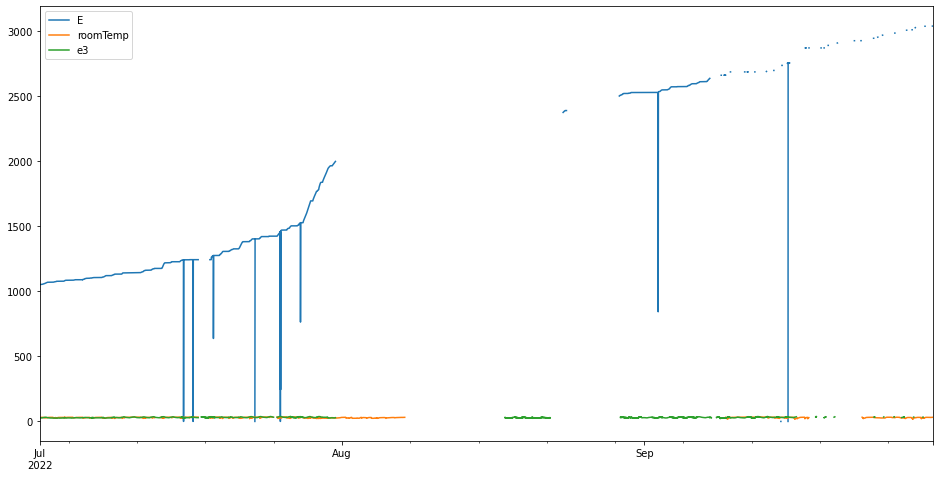

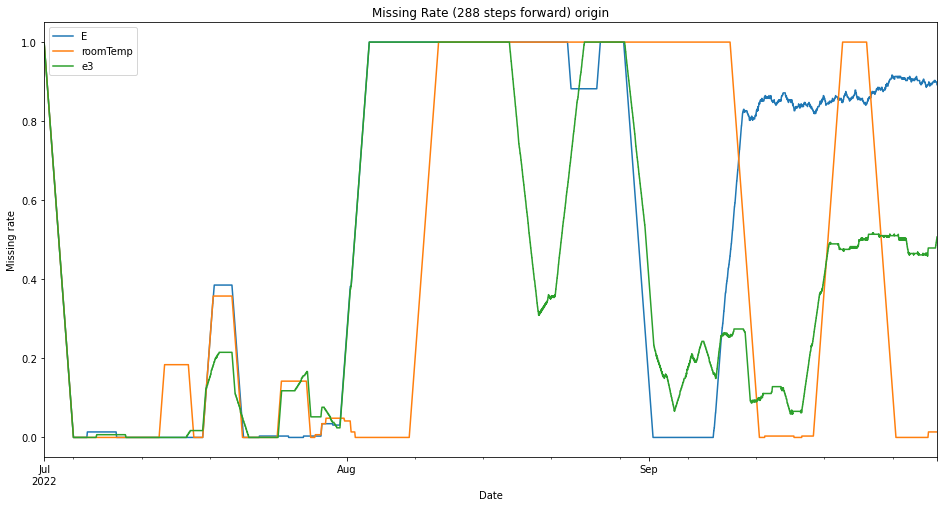

In [8]:
missing_rate = eval.cal_missing_rate(df, **params_process)

df.plot()
plt.legend(loc = 'upper left')
plt.gcf().set_size_inches(16, 8)
plt.show()

missing_rate.plot()
plt.plot(missing_rate.index, missing_rate)
plt.title('Missing Rate (' + str(params_process['step']) + ' steps forward) ' + 'origin')
plt.xlabel("Date")
plt.ylabel("Missing rate")
plt.legend(loc = 'upper left')
plt.gcf().set_size_inches(16, 8)
plt.show()

E minimal missing rate:  0.0
E average missing rate:  0.5490144720041426
E the closest optimal moment to the present:  2022-09-07 14:00:00 
------------------
roomTemp minimal missing rate:  0.0
roomTemp average missing rate:  0.4679104878572997
roomTemp the closest optimal moment to the present:  2022-09-28 12:00:00 
------------------
e3 minimal missing rate:  0.0
e3 average missing rate:  0.4153214719156458
e3 the closest optimal moment to the present:  2022-07-24 23:30:00 
------------------
The closest moment meets the condition(< 0.2) for multivariables:  2022-07-31 19:45:00 
------------------




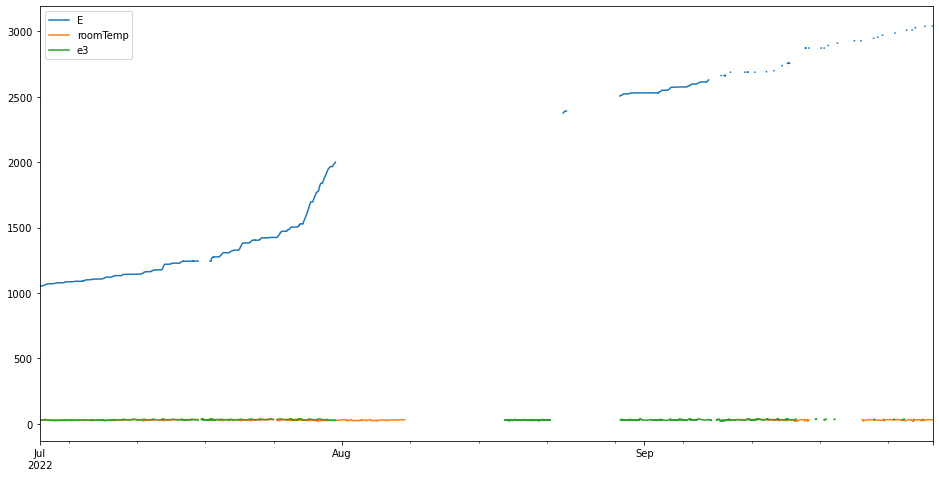

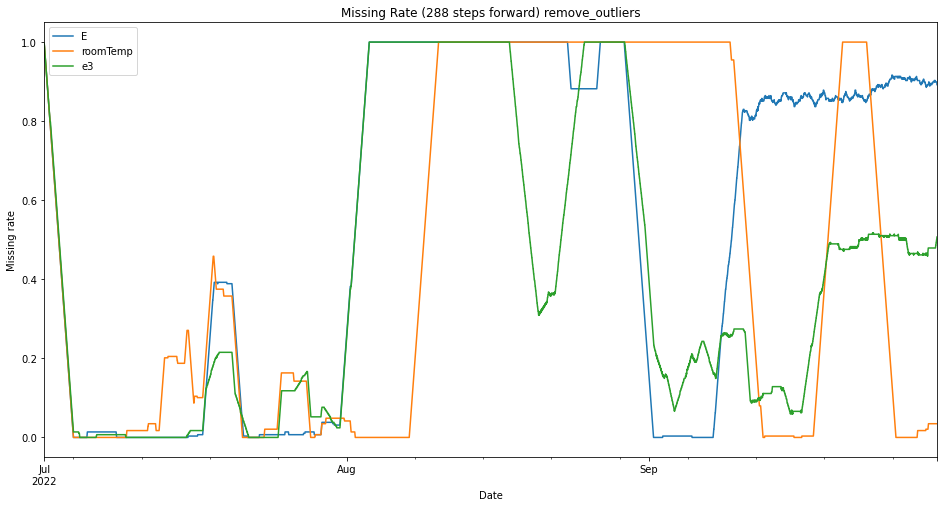

In [9]:
df_process = eval.remove_outliers(df, **params_process)
missing_rate_process = eval.cal_missing_rate(df_process, **params_process)

df_process.plot()
plt.legend(loc = 'upper left')
plt.gcf().set_size_inches(16, 8)
plt.show()

missing_rate_process.plot()
plt.plot(missing_rate_process.index, missing_rate_process)
plt.title('Missing Rate (' + str(params_process['step']) + ' steps forward) ' + 'remove_outliers')
plt.xlabel("Date")
plt.ylabel("Missing rate")
plt.legend(loc = 'upper left')
plt.gcf().set_size_inches(16, 8)
plt.show()

E minimal missing rate:  0.0
E average missing rate:  0.38055342220704924
E the closest optimal moment to the present:  2022-09-23 05:15:00 
------------------
roomTemp minimal missing rate:  0.0
roomTemp average missing rate:  0.4567641369894181
roomTemp the closest optimal moment to the present:  2022-09-30 13:00:00 
------------------
e3 minimal missing rate:  0.0
e3 average missing rate:  0.29679302410842306
e3 the closest optimal moment to the present:  2022-09-30 12:15:00 
------------------
The closest moment meets the condition(< 0.2) for multivariables:  2022-09-30 00:00:00 
------------------




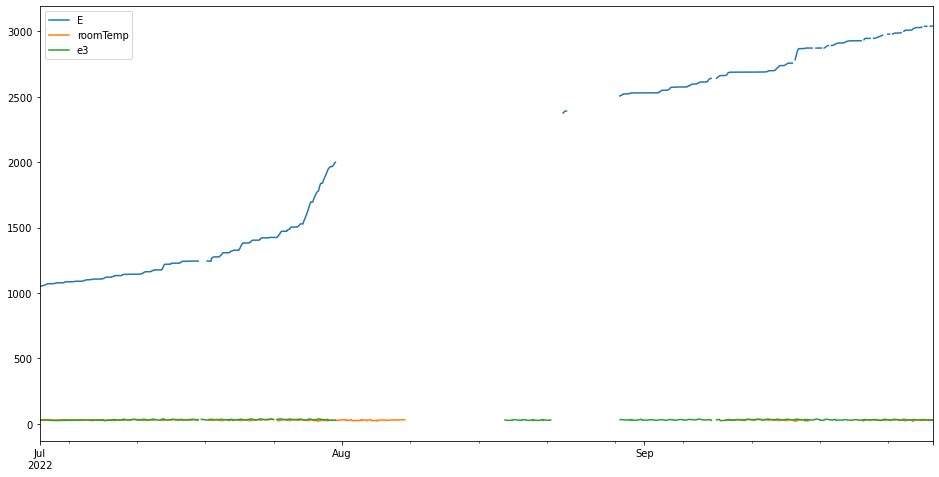

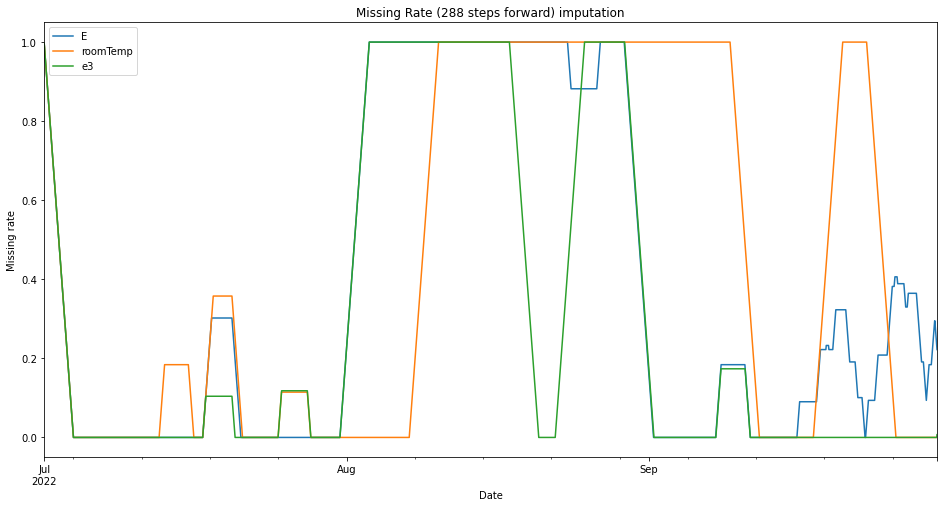

In [10]:
df_new = eval.linear_imputation(df_process, **params_process)
missing_rate_new = eval.cal_missing_rate(df_new, **params_process)

df_new.plot()
plt.legend(loc = 'upper left')
plt.gcf().set_size_inches(16, 8)
plt.show()

missing_rate_new.plot()
plt.plot(missing_rate_new.index, missing_rate_new)
plt.title('Missing Rate (' + str(params_process['step']) + ' steps forward) ' + 'imputation')
plt.xlabel("Date")
plt.ylabel("Missing rate")
plt.legend(loc = 'upper left')
plt.gcf().set_size_inches(16, 8)
plt.show()